# Aufgabenstellung
1. Nehmen Sie die Isothermen von $SF_6$ für acht Temperaturen auf. Eine Temperatur sollte oberhalb der kritischen Temperatur gewählt werden. Die Temperatur darf $55$°C nicht überschreiten, da sonst die Gefahr besteht, die Kapillare zu zerstören.

2. Zeichnen Sie die Isothermen und ermitteln Sie den Wert für den Sättigungsdruck ps im Bereich der Maxwell-Geraden (Koexistenz von Flüssigkeit und Dampf).

3. Stellen Sie $ln(p_s)$ als Funktion von ($1/T$) graphisch dar. Passen Sie die Dampfdruckgleichung an die Daten an und bestimmen Sie die mittlere molare Verdampfungswärme der untersuchten Substanz.

4. Ermitteln Sie die Stoffmenge der untersuchten Substanz.

5. Bestimmen Sie die Verdampfungswärme als Funktion der Temperatur mittels der Clausius-Clapeyron-Gleichung. Stellen Sie die Verdampfungswärme als Funktion von $T/T_K$ graphisch dar und
passen Sie ein Potenzgesetz an die Daten an.

# Aufgabe 2
Für die zweite Aufgabe suchen wir für jede Messung den Sättigungsdruck. Beim Sättigungsdruck handelt es sich um den Druck, bei dem es eine Koexistenz von Flüssigkeit und Dampf und es ein Plateau im pV-Diagramm gibt. Diese Plateau heißt, dass es einen konstanten Druck bei Volumenänderung gibt und tritt beim Phasenübergang von flüssig und gasförmig auf. Dieses Plateau kommt nur bei Temperaturen unterhalb der kritschen Temperatur $T_{k}$ vor, deshalb haben nicht alle von unseren Messdaten einen Wert von $p_s$.

Wir bestimmen den Wert, indem wir erstmal die einzelnen Isotherme plotten und innerhalb dieser Datensätze gucken, ob es zwischen benachbarten Druckwerten einen sehr geringen Unterschied gibt. Dieser wird dann als Sättigungsdruck ausgegeben.

Aufälligkeiten sind dabei dass die Isothermen bei höheren Temperaturen immer weniger ausgeprägt sind und die Plateau-Phase immer kürzer wird, bis sie wie in der letzten Isotherme gar nicht mehr zu erkenn ist oder wie in der vorletzten Isothermen, so schwach das sie sich nicht richtig auswerten lässt. Deshalb musste die Isotherme bei 46.5°C auch händisch ausgewertet werden. Dies liegt daran, dass es an dem Punkt die Unterschiede zwischen der flüssigen und der gasförmigen Phase verschwinden und somit keine Phasenübergang stattfindet. Was auch noch auffällt ist, das manche Messpunkt, bei dem Plateau etwas tiefer liegen als ihr linker Nachbarpunkt, was auf eine M;esungenauigkeit hindeutet. Während des MEssens hatten wir folgende Messunsicherheiten, da die Skalen auf den Messgeräten nicht kleiner waren.
Abweichung bei Volumina $\pm0.25\text{ml}$
Abweichung bei Druck $\pm25\text{kPa}$
 

Sättigungsdruck bei 31.5 °C: 27.42 10^5 Pa
Sättigungsdruck bei 34.4 °C: 29.25 10^5 Pa
Sättigungsdruck bei 37.5 °C: 31.50 10^5 Pa
Sättigungsdruck bei 40.5 °C: 34.00 10^5 Pa
Sättigungsdruck bei 43.5 °C: 36.25 10^5 Pa
Sättigungsdruck bei 46.5 °C: 38.75 10^5 Pa


<Figure size 4000x3000 with 0 Axes>

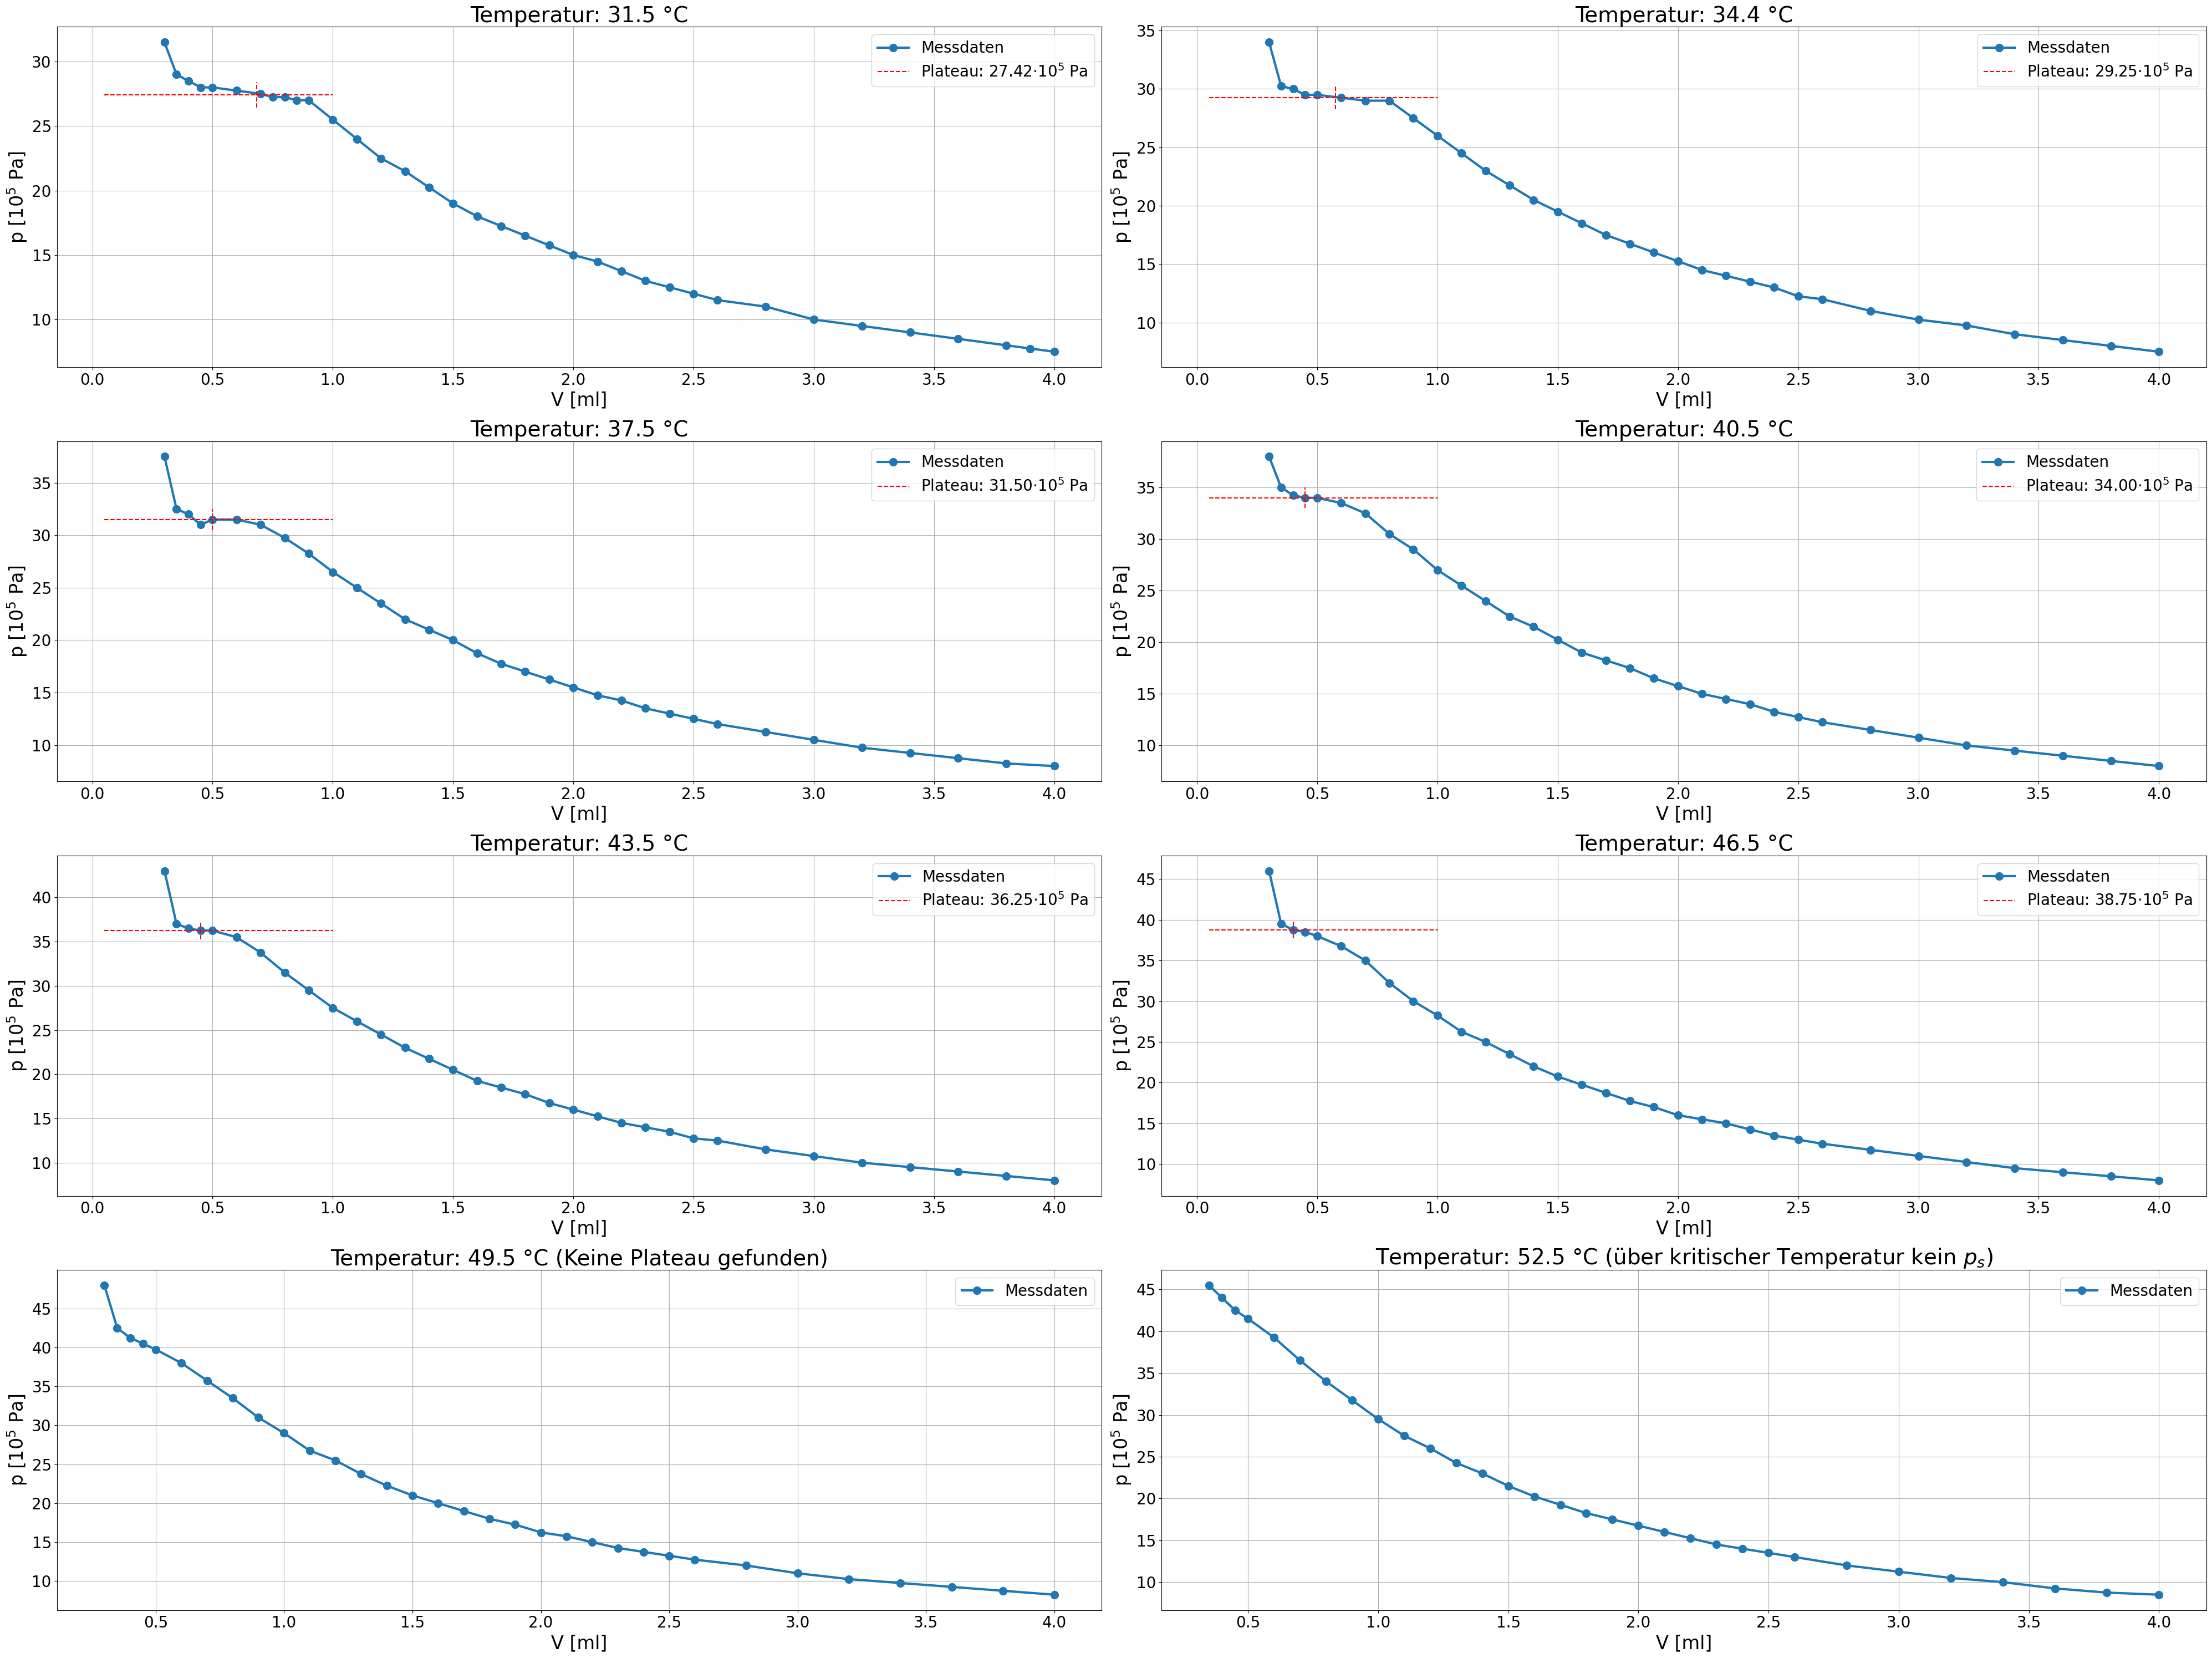

In [ ]:
# | label: fig-sättigungsdruck
# | fig-cap: Die Abbildung zeigt acht verschiedene Plots mit den Isothermen zu verscheidenen Temperaturen, dabei wurde der Sättigungsdruck $p_s$ mittels einer Plateau-Mittelung gemacht wurde. Dabei wurden die ersten 5 Plots maschinell herausgefunden, der 6te wurde händisch ermittelt und die zwei anderen konnten nicht ermittelt werden, da kein eindeutiges Plot ersichtlich war.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from natsort import natsorted
import os

#TODO: Abweichung eintragen Plot Hübsch machen

volumen = []
druck = []
temperatur = []

# Ordnerpfad anpassen
filepath = "Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

plateau_val = np.array([])
plateau_vol = np.array([])


for filename in csv_files:
    # CSV einlesen
    df = pd.read_csv(os.path.join(filepath, filename))
    df.columns = ['V[ml]', 'p [10^5 Pa]']

    # Temperatur aus dem Dateinamen extrahieren
    temp = filename[9:13]
    temp = temp.replace('_', '.')
    temp = float(temp)

    # Daten in Listen speichern
    volumen.append(df['V[ml]'])
    druck.append(df['p [10^5 Pa]'])
    temperatur.append(temp)

    # Sättigungsdruck berechnen
    # Differenz zwischen benachbarten Druckwerten berechnen
    dp = df['p [10^5 Pa]'].diff().abs()
    plateau_indices = dp[dp < 0.01].index  # Toleranz anpassen
    sättigungsdruck = df.loc[plateau_indices, 'p [10^5 Pa]'].mean()
    if np.isnan(sättigungsdruck):
        continue
    plateau_val= np.append(plateau_val, sättigungsdruck)
    plateau_vol = np.append(plateau_vol, df.loc[plateau_indices, 'V[ml]'].mean())
    print(f"Sättigungsdruck bei {temp} °C: {sättigungsdruck:.2f} 10^5 Pa")

# Händisch ausgelesene Daten (wenn dp < 0.26 findet er was für den 6ten Plot aber dann ist für die anderen Schlecht)
plateau_val= np.append(plateau_val, 38.75)
plateau_vol = np.append(plateau_vol, 0.4)
print(f"Sättigungsdruck bei 46.5 °C: 38.75 10^5 Pa")

# Plotten der Messdaten
plt.figure(figsize=(40, 30))
fig, axs = plt.subplots(4, 2, figsize=(40, 30))  # Re-declare figsize here too
axs = axs.flatten()

for i in range(len(axs)):
    axs[i].plot(volumen[i], druck[i], label='Messdaten', linewidth=3, marker='o', markersize=10)
    
    if i < 6:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C", fontsize=28)
        axs[i].hlines(plateau_val[i], 0.05, 1, colors='r', linestyles='--', label=f'Plateau: {plateau_val[i]:.2f}$\cdot 10^5$ Pa')
        axs[i].vlines(plateau_vol[i], plateau_val[i] - 1, plateau_val[i] + 1, colors='r', linestyles='--')
    elif i == 6:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C (Keine Plateau gefunden)", fontsize=28)
    else:
        axs[i].set_title(f"Temperatur: {temperatur[i]} °C (über kritischer Temperatur kein $p_s$)", fontsize=28)
    axs[i].set_xlabel("V [ml]", fontsize=24)
    axs[i].set_ylabel("p [$10^5$ Pa]", fontsize=24)
    axs[i].tick_params(axis='both', which='major', labelsize=20)
    axs[i].grid(True)
    axs[i].legend(fontsize=20)

plt.tight_layout()
plt.show()